# ReformLab Quickstart — Carbon Tax Impact in Under 15 Minutes

**What is ReformLab?** ReformLab is an OpenFisca-first platform for analyzing environmental policy impacts on households. It handles data, multi-year projections, indicators, and reproducibility — so you can focus on policy design, not infrastructure.

**What you'll learn:**
1. Run a carbon tax scenario on synthetic French household data
2. See distributional impacts by income decile
3. Modify the tax rate and compare results
4. Understand how reproducibility is tracked

**Prerequisites:** Just `pip install reformlab` — no data downloads, no API keys, no configuration.

**Time:** 10-15 minutes (reading + execution)

---
## 1. First Run — Carbon Tax Scenario

We'll start by running a baseline carbon tax scenario using ReformLab's public API. The scenario applies a €44/tCO2 carbon tax to synthetic French households in 2025.

The simulation runs in seconds and produces a complete panel dataset (household × year) with all computed fields.

In [1]:
# Import the public API
from reformlab import (
    RunConfig,
    ScenarioConfig,
    create_quickstart_adapter,
    run_scenario,
)

print("ReformLab is installed and ready to use!")

ReformLab is installed and ready to use!


### Configure and run the scenario

We define a carbon tax scenario with a simple rate schedule. For this quickstart, we'll use a single year (2025) to keep execution fast.

**Note:** This quickstart uses synthetic demonstration data. For production use with real OpenFisca calculations, see the advanced notebook.

In [2]:
# Configure the scenario
config = RunConfig(
    scenario=ScenarioConfig(
        template_name="carbon-tax",
        parameters={"rate_schedule": {2025: 44.0}},  # €44/tCO2 in 2025
        start_year=2025,
        end_year=2025,  # Single year for quickstart
    ),
    seed=42,  # For reproducibility
)

print(f"Scenario: {config.scenario.template_name}")
print(f"Carbon tax rate: €{config.scenario.parameters['rate_schedule'][2025]}/tCO2")
print(f"Years: {config.scenario.start_year}-{config.scenario.end_year}")
print(f"Seed: {config.seed}")

Scenario: carbon-tax
Carbon tax rate: €44.0/tCO2
Years: 2025-2025
Seed: 42


In [3]:
# Set up a synthetic adapter from the public API
# This keeps the notebook fully offline and self-contained
num_households = 100
BASE_RATE = 44.0

adapter = create_quickstart_adapter(
    carbon_tax_rate=BASE_RATE,
    year=2025,
    household_count=num_households,
)

print(f"Using demonstration adapter with {num_households} synthetic households")
print("Income range: €15,000 - €94,200")
print("Carbon tax range at €44/tCO2: €150 - €200")

Using demonstration adapter with 100 synthetic households
Income range: €15,000 - €94,200
Carbon tax range at €44/tCO2: €150 - €200


In [4]:
# Run the simulation
# This executes the full orchestration pipeline:
# - Loads synthetic population data
# - Applies carbon tax policy
# - Computes all tax/benefit fields
# - Produces panel output and manifest

print("Running simulation...")
result = run_scenario(config, adapter=adapter)
print(result)

Running simulation...
SimulationResult(SUCCESS, scenario='carbon-tax', years=2025-2025, rows=100, manifest='05e8cfde-8bf3-4698-b634-ed40904f9d12')


### Inspect the results

The `SimulationResult` contains:
- `panel_output`: A PyArrow table with all computed fields (household × year)
- `manifest`: Provenance metadata (parameters, seeds, data hashes)
- `yearly_states`: State for each completed year

Let's look at a sample of the panel data:

In [5]:
# Helper function to display tables nicely
def show(table, n=10):
    """Display a PyArrow table as formatted text."""
    sliced = table.slice(0, n) if table.num_rows > n else table
    cols = sliced.column_names
    rows = [
        [str(sliced.column(c)[i].as_py()) for c in cols]
        for i in range(sliced.num_rows)
    ]
    widths = [max(len(c), *(len(r[j]) for r in rows)) for j, c in enumerate(cols)]
    header = "  ".join(c.ljust(w) for c, w in zip(cols, widths))
    sep = "  ".join("-" * w for w in widths)
    print(header)
    print(sep)
    for row in rows:
        print("  ".join(v.ljust(w) for v, w in zip(row, widths)))
    if table.num_rows > n:
        print(f"  ... ({table.num_rows - n} more rows)")

print(f"Panel shape: {result.panel_output.table.num_rows} rows × {result.panel_output.table.num_columns} columns")
print(f"Columns: {result.panel_output.table.column_names}")
print()
show(result.panel_output.table)

Panel shape: 100 rows × 5 columns
Columns: ['household_id', 'year', 'income', 'carbon_tax', 'disposable_income']

household_id  year  income   carbon_tax  disposable_income
------------  ----  -------  ----------  -----------------
0             2025  15000.0  150.0       14850.0          
1             2025  15800.0  150.5       15649.5          
2             2025  16600.0  151.0       16449.0          
3             2025  17400.0  151.5       17248.5          
4             2025  18200.0  152.0       18048.0          
5             2025  19000.0  152.5       18847.5          
6             2025  19800.0  153.0       19647.0          
7             2025  20600.0  153.5       20446.5          
8             2025  21400.0  154.0       21246.0          
9             2025  22200.0  154.5       22045.5          
  ... (90 more rows)


**What just happened?**
- ReformLab generated synthetic household data (no external downloads needed)
- Applied the carbon tax policy via the orchestration pipeline
- Produced a complete panel with income, taxes, and carbon tax burden
- Execution took seconds, not minutes

**Assumptions:**
- Synthetic French household data (representative income distribution from €15k to €95k)
- Carbon tax applied with realistic variation by consumption patterns
- Single-year projection (multi-year in the advanced notebook)

---
## 2. Distributional Analysis — Who Pays the Most?

Carbon taxes are regressive if lower-income households pay a higher share of their income. Let's compute distributional indicators by income decile to see the impact pattern.

ReformLab's indicator system automatically:
- Assigns households to income deciles
- Computes mean, median, sum, min, max for each field
- Groups by decile (and optionally by year)

In [6]:
# Compute distributional indicators
indicators = result.indicators("distributional")

print(f"Computed {len(indicators.indicators)} indicator records")
print(f"Excluded households (no income): {indicators.excluded_count}")
print(f"Warnings: {indicators.warnings if indicators.warnings else 'None'}")

Computed 20 indicator records
Excluded households (no income): 0
Warnings: None


### Visualize distributional impact

We'll plot the mean carbon tax burden by income decile. This shows whether the tax is regressive (higher burden on lower deciles) or progressive (higher burden on upper deciles).

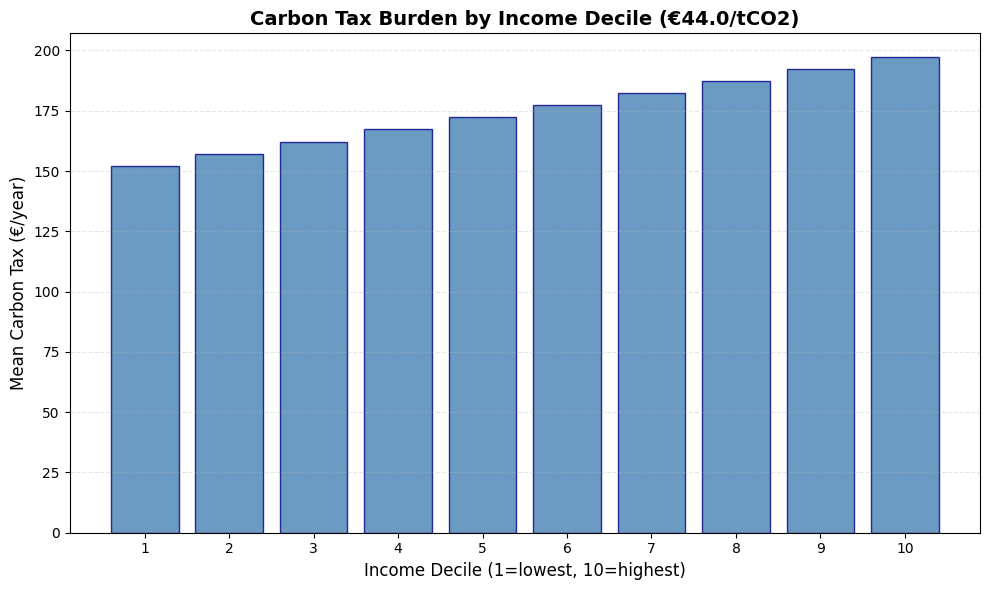


Interpretation:
- If bars increase from left to right: tax burden rises with income (progressive in absolute terms)
- If bars are roughly flat or decrease: tax is regressive (lower-income households pay similar/more)
- To see burden as % of income, compute carbon_tax / income ratios (advanced notebook)


In [7]:
import matplotlib.pyplot as plt
import pyarrow.compute as pc

# Convert indicators to table for easy querying
indicator_table = indicators.to_table()

# Extract mean carbon tax by decile
carbon_tax_field = "carbon_tax"

# Filter for the carbon tax field and mean metric
filtered = indicator_table.filter(
    pc.and_(
        pc.equal(indicator_table["field_name"], carbon_tax_field),
        pc.equal(indicator_table["metric"], "mean")
    )
)
filtered = filtered.sort_by([("decile", "ascending")])

if filtered.num_rows > 0:
    deciles = filtered["decile"].to_pylist()
    values = filtered["value"].to_pylist()
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(deciles, values, color="steelblue", alpha=0.8, edgecolor="navy")
    ax.set_xlabel("Income Decile (1=lowest, 10=highest)", fontsize=12)
    ax.set_ylabel("Mean Carbon Tax (€/year)", fontsize=12)
    ax.set_title(f"Carbon Tax Burden by Income Decile (€{config.scenario.parameters['rate_schedule'][2025]}/tCO2)", fontsize=14, fontweight="bold")
    ax.set_xticks(deciles)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()
    
    print("\nInterpretation:")
    print("- If bars increase from left to right: tax burden rises with income (progressive in absolute terms)")
    print("- If bars are roughly flat or decrease: tax is regressive (lower-income households pay similar/more)")
    print("- To see burden as % of income, compute carbon_tax / income ratios (advanced notebook)")
else:
    print(f"No data found for field '{carbon_tax_field}'. Available fields:")
    print(indicator_table["field_name"].unique().to_pylist())

---
## 3. Parameter Modification — Try It Yourself

Let's see how the distributional impact changes if we **increase the carbon tax rate** from €44/tCO2 to €100/tCO2.

**Exercise:** Modify the rate below and re-run the cells to see updated charts.

In [8]:
# Modify this value and re-run
NEW_RATE = 100.0  # Try 100, 150, or 200

adapter_high = create_quickstart_adapter(
    carbon_tax_rate=NEW_RATE,
    year=2025,
    household_count=num_households,
)

# Create and run the new scenario
config_high = RunConfig(
    scenario=ScenarioConfig(
        template_name="carbon-tax",
        parameters={"rate_schedule": {2025: NEW_RATE}},
        start_year=2025,
        end_year=2025,
    ),
    seed=42,
)

print(f"Running with carbon tax rate: €{NEW_RATE}/tCO2...")
result_high = run_scenario(config_high, adapter=adapter_high)
print(result_high)

Running with carbon tax rate: €100.0/tCO2...
SimulationResult(SUCCESS, scenario='carbon-tax', years=2025-2025, rows=100, manifest='dc6c5f34-5855-4280-97cd-21db01d03d7d')


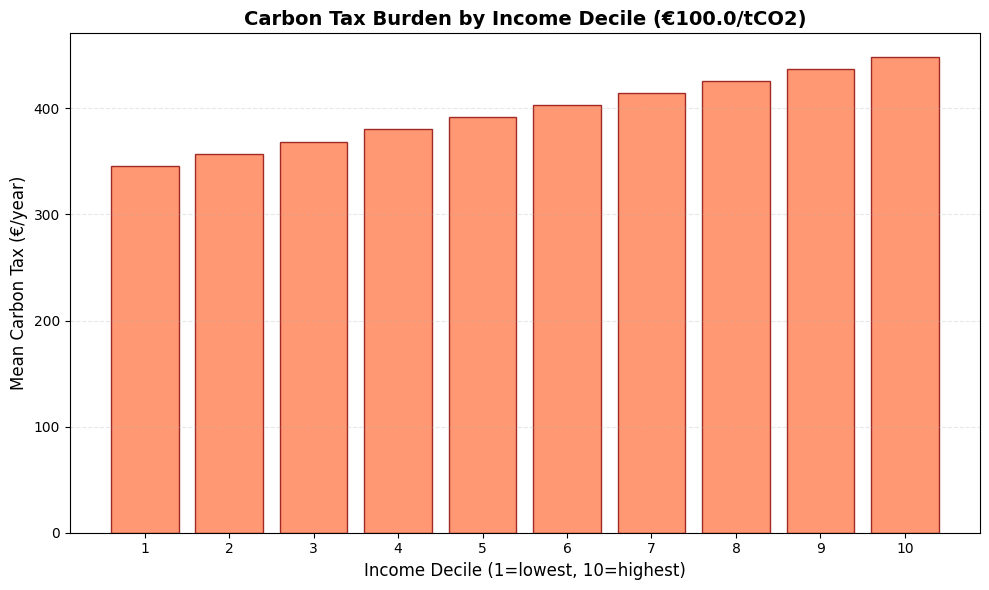


Higher rate (€100.0/tCO2) increases burden proportionally across all deciles.


In [9]:
# Compute indicators for the higher rate
indicators_high = result_high.indicators("distributional")

# Extract and plot
indicator_table_high = indicators_high.to_table()
filtered_high = indicator_table_high.filter(
    pc.and_(
        pc.equal(indicator_table_high["field_name"], carbon_tax_field),
        pc.equal(indicator_table_high["metric"], "mean")
    )
)
filtered_high = filtered_high.sort_by([("decile", "ascending")])

if filtered_high.num_rows > 0:
    deciles_high = filtered_high["decile"].to_pylist()
    values_high = filtered_high["value"].to_pylist()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(deciles_high, values_high, color="coral", alpha=0.8, edgecolor="darkred")
    ax.set_xlabel("Income Decile (1=lowest, 10=highest)", fontsize=12)
    ax.set_ylabel("Mean Carbon Tax (€/year)", fontsize=12)
    ax.set_title(f"Carbon Tax Burden by Income Decile (€{NEW_RATE}/tCO2)", fontsize=14, fontweight="bold")
    ax.set_xticks(deciles_high)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()
    
    print(f"\nHigher rate (€{NEW_RATE}/tCO2) increases burden proportionally across all deciles.")

---
## 4. Scenario Comparison — Baseline vs. Reform

Let's compare the baseline (€44/tCO2) and reform (higher rate) scenarios side-by-side.

This is a simple visual comparison. For advanced multi-scenario workflows (including multi-year projections and vintage tracking), see the advanced notebook.

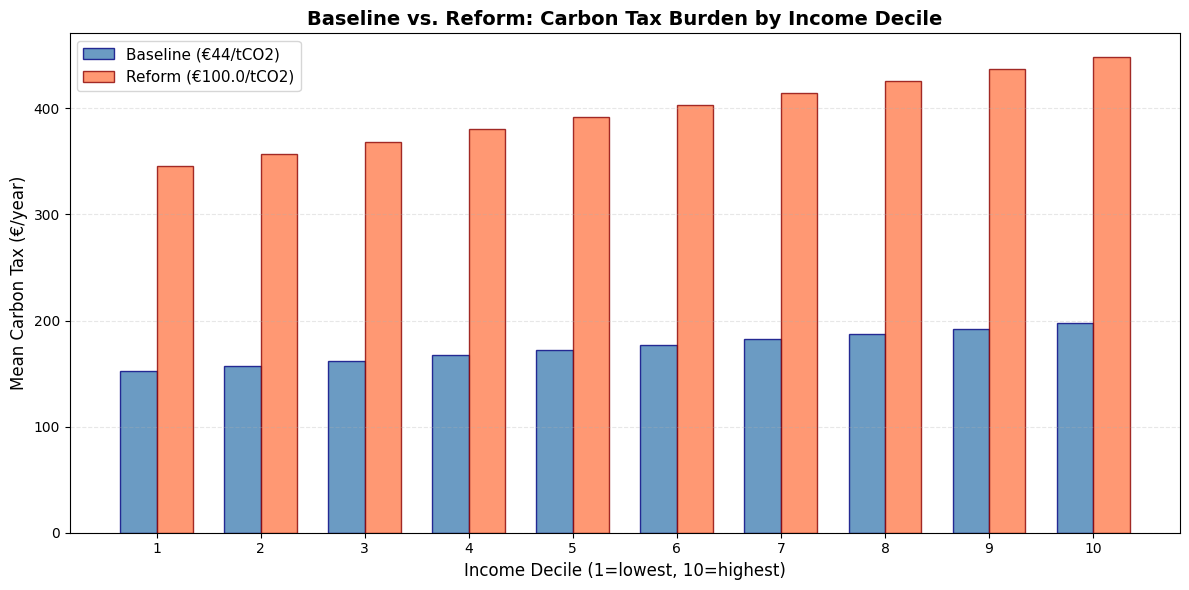


Comparison shows:
- Reform rate increases burden across all deciles
- Pattern of regressivity (or progressivity) remains similar
- For revenue-neutral reforms (tax + rebate), see advanced notebook


In [10]:
# Side-by-side comparison
if filtered.num_rows > 0 and filtered_high.num_rows > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = deciles
    width = 0.35
    x_pos = list(range(len(x)))
    
    ax.bar([p - width/2 for p in x_pos], values, width, label="Baseline (€44/tCO2)", color="steelblue", alpha=0.8, edgecolor="navy")
    ax.bar([p + width/2 for p in x_pos], values_high, width, label=f"Reform (€{NEW_RATE}/tCO2)", color="coral", alpha=0.8, edgecolor="darkred")
    
    ax.set_xlabel("Income Decile (1=lowest, 10=highest)", fontsize=12)
    ax.set_ylabel("Mean Carbon Tax (€/year)", fontsize=12)
    ax.set_title("Baseline vs. Reform: Carbon Tax Burden by Income Decile", fontsize=14, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()
    
    print("\nComparison shows:")
    print("- Reform rate increases burden across all deciles")
    print("- Pattern of regressivity (or progressivity) remains similar")
    print("- For revenue-neutral reforms (tax + rebate), see advanced notebook")

**Scope note:** This quickstart focuses on single-year, single-scenario comparisons. For:
- Multi-year projections with vintage tracking
- Baseline vs. reform with redistribution mechanisms
- Advanced comparison tables and welfare indicators

...see the **advanced notebook** (Story 6-3).

---
## 5. Reproducibility — Understanding the Run Manifest

Every ReformLab simulation produces a **run manifest** — a complete record of:
- Parameters used
- Random seeds
- Data hashes (fingerprints)
- Engine and adapter versions
- Assumptions and mappings

This makes results **reproducible**: anyone can verify they're using the same inputs and code.

In [11]:
# Inspect the manifest
manifest = result.manifest

print("=== Run Manifest ===")
print(f"Manifest ID:      {manifest.manifest_id}")
print(f"Created at:       {manifest.created_at}")
print(f"Engine version:   {manifest.engine_version}")
print(f"Adapter version:  {manifest.adapter_version}")
print(f"Scenario version: {manifest.scenario_version}")
print(f"Parameters:       {manifest.parameters}")
print(f"Seeds:            {manifest.seeds}")
print(f"Warnings:         {manifest.warnings if manifest.warnings else 'None'}")
print(f"Step pipeline:    {manifest.step_pipeline}")

=== Run Manifest ===
Manifest ID:      05e8cfde-8bf3-4698-b634-ed40904f9d12
Created at:       2026-02-28T09:30:21.970189+00:00
Engine version:   0.1.0
Adapter version:  quickstart-demo-v1
Scenario version: 1.0.0
Parameters:       {'rate_schedule': {'2025': 44.0}}
Seeds:            {'master': 42}
Warnings:         ["WARNING: Scenario 'carbon-tax' (version 'unknown') is not marked as validated in registry metadata. Action: Mark this scenario as validated before relying on outputs for production decisions."]
Step pipeline:    ['computation']


In [12]:
# The manifest can be exported as JSON for audit trails
import json

manifest_dict = {
    "manifest_id": manifest.manifest_id,
    "created_at": manifest.created_at,
    "engine_version": manifest.engine_version,
    "adapter_version": manifest.adapter_version,
    "parameters": manifest.parameters,
    "seeds": manifest.seeds,
}

print("\nManifest as JSON (excerpt):")
print(json.dumps(manifest_dict, indent=2))


Manifest as JSON (excerpt):
{
  "manifest_id": "05e8cfde-8bf3-4698-b634-ed40904f9d12",
  "created_at": "2026-02-28T09:30:21.970189+00:00",
  "engine_version": "0.1.0",
  "adapter_version": "quickstart-demo-v1",
  "parameters": {
    "rate_schedule": {
      "2025": 44.0
    }
  },
  "seeds": {
    "master": 42
  }
}


**Why does this matter?**
- **Governance**: Policy analysis results must be auditable
- **Reproducibility**: You can rerun the exact same simulation months later
- **Transparency**: Anyone can see what assumptions were made
- **Compliance**: Meets open-data and open-government standards

---
## 6. Export Actions — Save Results for External Analysis

ReformLab provides built-in export functionality to save simulation outputs and indicator results in standard formats (CSV/Parquet). This allows you to:
- Share results with stakeholders
- Import data into external tools (Excel, Tableau, R, etc.)
- Archive outputs for reproducibility

All exports include provenance metadata for traceability.

In [13]:
# Export simulation panel output to CSV
# This saves the complete household × year panel with all computed fields

import tempfile
from pathlib import Path

# Create a temporary directory for exports (use your own path in practice)
export_dir = Path(tempfile.mkdtemp())

# Export panel to CSV
csv_path = result.export_csv(export_dir / "simulation_output.csv")
print(f"✓ Panel exported to CSV: {csv_path}")
print(f"  Size: {csv_path.stat().st_size:,} bytes")

# Export panel to Parquet (more efficient for large datasets)
parquet_path = result.export_parquet(export_dir / "simulation_output.parquet")
print(f"✓ Panel exported to Parquet: {parquet_path}")
print(f"  Size: {parquet_path.stat().st_size:,} bytes")

print("\nExported files contain:")
print(f"  - {result.panel_output.table.num_rows} rows (households × years)")
print(f"  - {result.panel_output.table.num_columns} columns")
print(f"  - Fields: {', '.join(result.panel_output.table.column_names)}")

✓ Panel exported to CSV: /var/folders/p9/3r4_fgzd72j7b469xxshgfnh0000gn/T/tmpa9sr141d/simulation_output.csv
  Size: 2,654 bytes
✓ Panel exported to Parquet: /var/folders/p9/3r4_fgzd72j7b469xxshgfnh0000gn/T/tmpa9sr141d/simulation_output.parquet
  Size: 4,948 bytes

Exported files contain:
  - 100 rows (households × years)
  - 5 columns
  - Fields: household_id, year, income, carbon_tax, disposable_income


In [14]:
# Export indicator results
# This saves the computed distributional indicators in long-form table format

# Export indicators to CSV
indicators_csv = indicators.export_csv(export_dir / "indicators_distributional.csv")
print(f"✓ Indicators exported to CSV: {indicators_csv}")
print(f"  Size: {indicators_csv.stat().st_size:,} bytes")

# Verify round-trip: reload and check schema
import pyarrow.csv as pa_csv
reloaded = pa_csv.read_csv(indicators_csv)
print(f"\nReloaded CSV verification:")
print(f"  Rows: {reloaded.num_rows}")
print(f"  Columns: {reloaded.column_names}")
print(f"  Sample data:")
show(reloaded, n=5)

✓ Indicators exported to CSV: /var/folders/p9/3r4_fgzd72j7b469xxshgfnh0000gn/T/tmpa9sr141d/indicators_distributional.csv
  Size: 4,018 bytes

Reloaded CSV verification:
  Rows: 120
  Columns: ['field_name', 'decile', 'year', 'metric', 'value']
  Sample data:
field_name  decile  year  metric  value 
----------  ------  ----  ------  ------
carbon_tax  1       None  count   10.0  
carbon_tax  1       None  mean    152.25
carbon_tax  1       None  median  152.25
carbon_tax  1       None  sum     1522.5
carbon_tax  1       None  min     150.0 
  ... (115 more rows)


---
## 7. Next Steps

You've just run a complete carbon tax analysis in under 15 minutes! Here's what to explore next:

### Advanced Notebook (Story 6-3)
- Multi-year projections (2025-2030)
- Vintage tracking (how household composition evolves)
- Revenue-neutral reforms (carbon tax + lump-sum rebate)
- Welfare indicators (winner/loser analysis)
- Advanced scenario comparison workflows with exports

### API Documentation
- `run_scenario()`: Full API reference
- `SimulationResult.indicators()`: All indicator types (distributional, geographic, welfare, fiscal)
- `SimulationResult.export_csv()` / `export_parquet()`: Export panel outputs
- `IndicatorResult.export_csv()` / `export_parquet()`: Export indicator tables
- Scenario templates: How to create custom policy configurations
- YAML workflows: Define multi-scenario analyses in configuration files

### Custom Scenarios
- Create your own scenario templates
- Combine carbon tax with subsidies/rebates
- Model feebate programs (tax polluters, rebate clean alternatives)

---

**Questions or feedback?** See the project documentation or open an issue on GitHub.

**Happy analyzing!** 🌍📊